# 🐉 The Pokémon Classification Challenge


### 📊 About the Dataset
This dataset contains the base battle statistics of hundreds of Pokémon (fictional creatures used in video game battles).
* **Official Source:** [Kaggle - Pokemon with Stats](https://www.kaggle.com/datasets/abcsds/pokemon)
* **The Features:** Numerical stats like Health Points (`HP`), `Attack`, `Defense`, and `Speed` and Categorical stats like `Type 1` and `Type 2`.
* **The Target:** A binary flag (`Legendary`) indicating whether a Pokémon is a rare, legendary creature (`True`) or a standard, common creature (`False`).

### 🎯 Learning Objectives
By completing this notebook, you will put recent lecture theory into practice by:
1. **Performing EDA:** Visualizing data distributions.
2. **Building Scikit-Learn Pipelines:** Automating data scaling (`StandardScaler`) and model training while preventing data leakage.
3. **Comparing Algorithms:** Observing how distance-based models (Logistic Regression, SVM) differ from tree-based models (Decision Trees, Random Forests).
4. **Evaluating Imbalanced Data:** Discover how the dataset imbalance affects the evaluation metrics and how we can improve the model

## SECTION 1: Initial Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Import the 4 models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
url = "https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv"
df = pd.read_csv(url)
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


### 1. Prepare numeric data for EDA (Drop the categorical stats and Pokemon names)

In [4]:
df_numeric = df.drop(columns=['#', 'Name', 'Type 1', 'Type 2'])

df_numeric.head()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,318,45,49,49,65,65,45,1,False
1,405,60,62,63,80,80,60,1,False
2,525,80,82,83,100,100,80,1,False
3,625,80,100,123,122,120,80,1,False
4,309,39,52,43,60,50,65,1,False


In [18]:
df_numeric = df_numeric.replace({'Legendary': {'False': 0, 'True': 1}})
display(df_numeric.head(5))
display(df_numeric.tail(5))

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,318,45,49,49,65,65,45,1,False
1,405,60,62,63,80,80,60,1,False
2,525,80,82,83,100,100,80,1,False
3,625,80,100,123,122,120,80,1,False
4,309,39,52,43,60,50,65,1,False


,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,600,50,100,150,100,150,50,6,True
796,700,50,160,110,160,110,110,6,True
797,600,80,110,60,150,130,70,6,True
798,680,80,160,60,170,130,80,6,True
799,600,80,110,120,130,90,70,6,True


In [27]:
df_numeric.groupby('Legendary').count()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
Legendary,,,,,,,,
False,735,735,735,735,735,735,735,735
True,65,65,65,65,65,65,65,65


In [20]:
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Total       800 non-null    int64
 1   HP          800 non-null    int64
 2   Attack      800 non-null    int64
 3   Defense     800 non-null    int64
 4   Sp. Atk     800 non-null    int64
 5   Sp. Def     800 non-null    int64
 6   Speed       800 non-null    int64
 7   Generation  800 non-null    int64
 8   Legendary   800 non-null    bool 
dtypes: bool(1), int64(8)
memory usage: 50.9 KB


In [13]:
# Missing Values
df_numeric.isnull().sum()

Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

In [12]:
df_numeric.isnull()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
795,False,False,False,False,False,False,False,False,False
796,False,False,False,False,False,False,False,False,False
797,False,False,False,False,False,False,False,False,False
798,False,False,False,False,False,False,False,False,False


## SECTION 2: Exploratory Data Analysis (EDA)
**Task 1 :** Explore general dataset stats: E.g. Dataset size, number of Pokémon in each class, etc." (Fun fact: 'Pokémon' is both the singular and plural form!)


**Task 2:** Explore the dataset by plotting different metrics.

*Hint:* you can use **sns.pairplot()** for this task

In [ ]:
df_numeric.shape

(800, 9)

In [21]:
df_numeric.describe()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


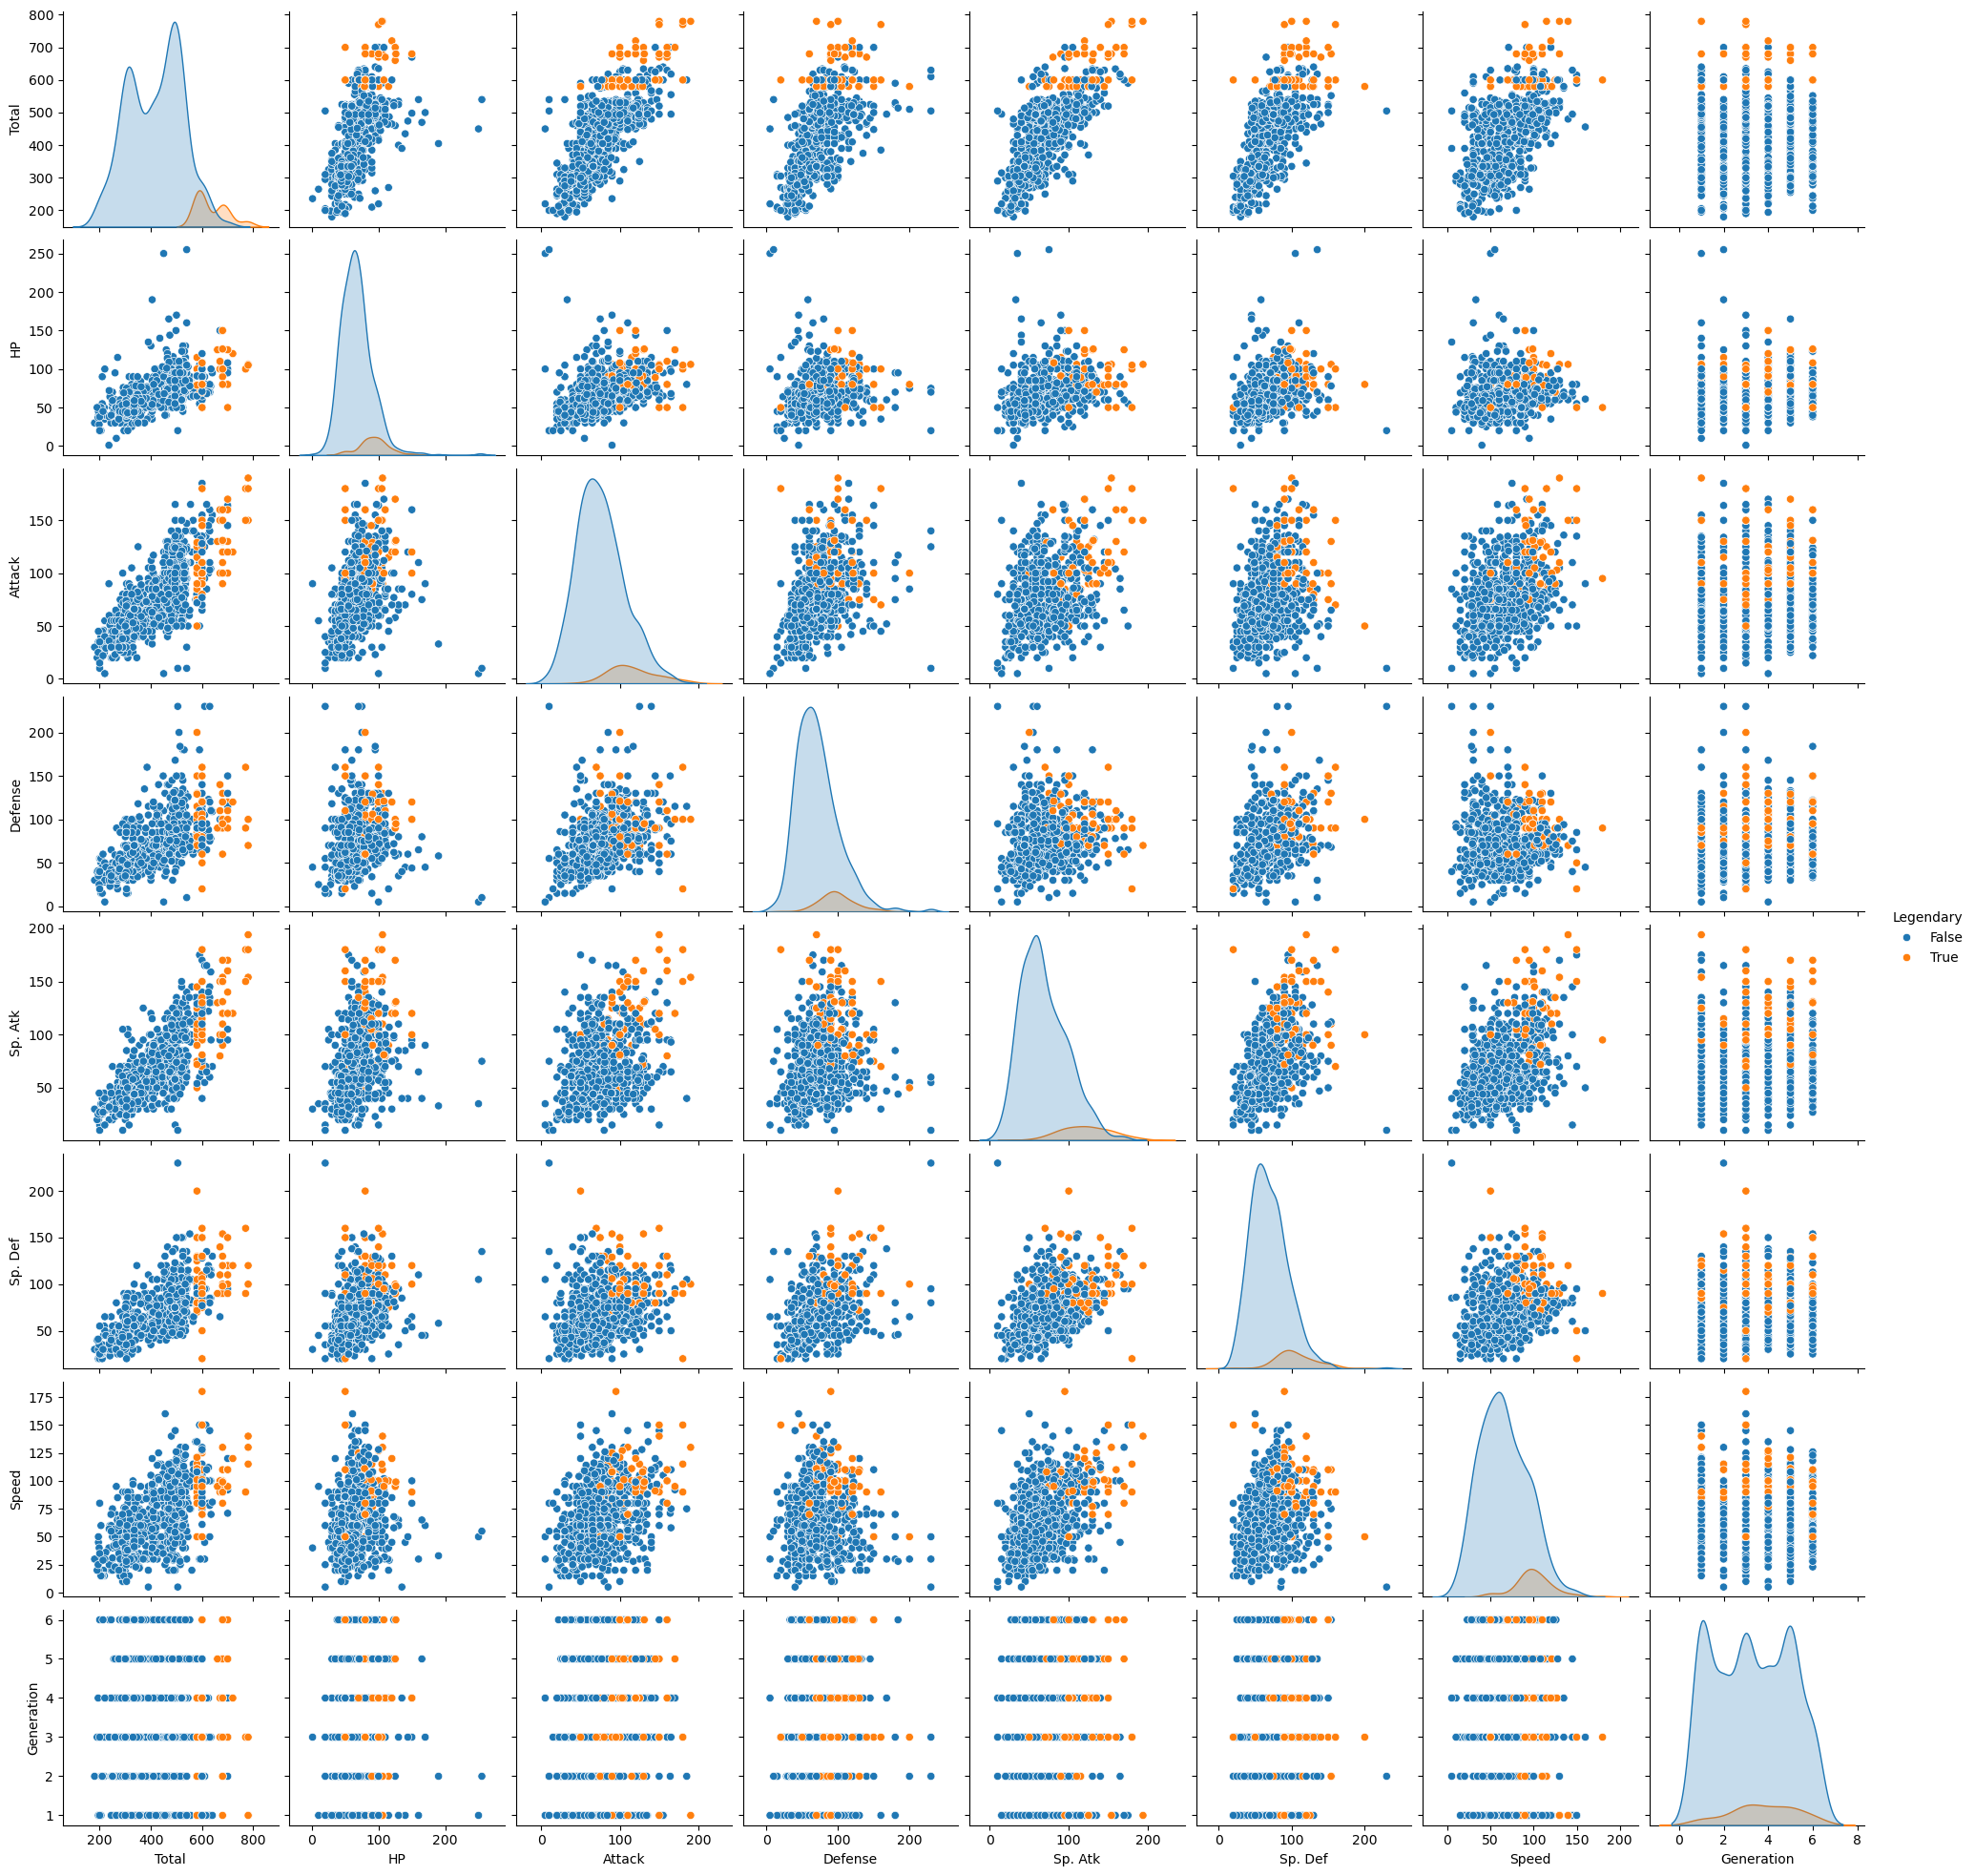

In [59]:
sns.pairplot(df_numeric, hue='Legendary')

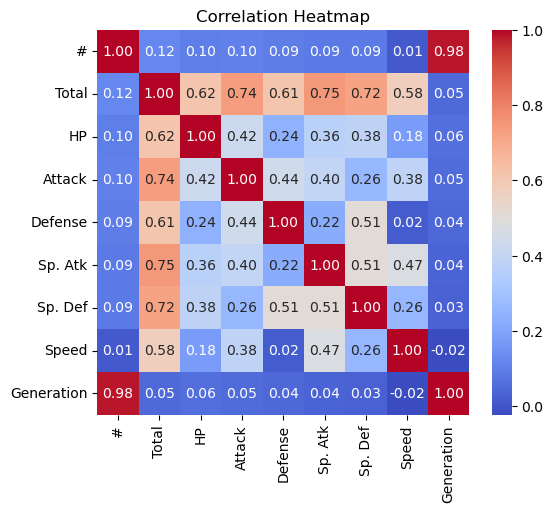

In [24]:

numeric_df = df.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Visualize with a Seaborn Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

## SECTION 3: Data Preparation
**Task:** Drop text columns, define features (X) and target (y), and split into 80/20 train/test sets.

*Hint:* read the documentation for **train_test_split()** function to better understand available parameters

In [57]:
X = df_numeric.drop(['Legendary', 'Attack', 'HP', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation'], axis=1)
y = df_numeric['Legendary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape[0]}")
print(f"X_test shape: {X_test.shape[0]}")


from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1)
svm.fit(X_train, y_train)
y_predicted = svm.predict(X_test)


X_train shape: 640
X_test shape: 160


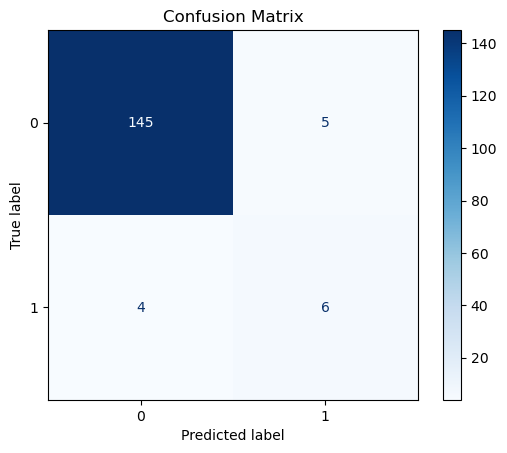

In [ ]:
cm = confusion_matrix(y_test, y_predicted)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()




#### F1_Score and Recall to get precision 

## SECTION 4: The Model Pipelines
**Task:** Create a model pipeline for one of given models:
- Logistic Regression (GROUP 1)
- Support Vector Machine (GROUP 2)
- Decision Tree Pipeline (GROUP 3)
- Random Forest Pipeline (GROUP 4)

and then train the pipeline on the daset and do an inference run on test dataset.

*Hint:* Recall 3 previous lectures on how to create a pipeline and what are the aspects you should think of while training the model.

## SECTION 5: Evaluation and Interpetation
**Task:** evaluate the model and using the metrics we have learned, understand and describe the results.

*Hint:* you can use the Confusion Matrix and Classification Report for this section


## SECTION 6: How can we improve the model?
**Task:** Understande the challendes the current model faces and try to solve them. Train the model again and compare the results.


## Section 7: Present the results to other students

- Chose one student from the team to present the results
- Explain briefly what model did you use and what are the core work principles of this model
- Present the Confusion Matrix and Classification Report and explain it.
- Explain the weaknesses of the model and how did you try to mitigate them.